# Water Heaters

This notebook will explore different control strategies for resistance and heat pump water heaters. As described in the lecture slides, all water heaters can be represented in the form of a thermal battery with with the state variable $x$ represnting the thermal capacity of the water heater. The dynamics of the water heater can be represented in continuous time as:
$$
\frac{\text d x}{\text d t} = - \frac x \tau + q_c + w , \ \underline x \leq x \leq \overline x \tag{1}
$$

where, $x = C(T-T_{LS})$ represents the thermal energy stored in the water heater above the datum temperature $T_{LS}$ (the temperature of water entering the water heater), $C$ is the thermal capacitance of the water heater, $\tau = RC$ is the time constant of the water heater, $q_c$ is the charging rate (heating rate) of the water heater, and $w = (T_a - T_\text{LS})/R - q_d$ is the disturbance (hot water draw plus ambient heat transfer). The lower and upper energy limits of the water heater are represented by $\underline x$ and $\overline x$, respectively. The discretizezd version of the dynamics in (1) with a time step of $\Delta t$ is given by:
$$
x(k+1) = ax(k) + (1-a) \tau (q_c(k) + w(k))  , \ \text{if } \tau < \infty \tag{2}
$$

where $a = e^{-\Delta t/\tau}$.

## Water Heater Parameters
Consider a 50-gallon water heater with U-value of $0.0005 kW/m^2/C$. The values of R and C can be calculated as follows:

In [98]:
def get_water_heater_parameters(V, U):
    """
    % getWaterHeaterParameters defines the thermal resistance and capacitance
    % based on the tank volume and thermal transmittance.
    %
    % Inputs:
    %   V, the water volume in m^3
    %   U, the tank wall thermal transmittance in kW/m^2/C
    %
    % Outputs:
    %   R, the tank wall thermal resistance in C/kW
    %   C, the water thermal resistance in kWh/C
    """
    # Geometry
    h = 1.5  # Tank height, meters
    r = np.sqrt(V / (np.pi * h))  # Tank radius, meters
    A = 2 * V * (1 / r + 1 / h)  # Tank wall surface area, m^2

    # Thermal resistance and capacitance
    R = 1 / (U * A)  # Tank wall thermal resistance, C/kW
    C = 1.2 * V  # Tank thermal capacitance, kWh/C

    return R, C

## Water Heater Draw
The hourly water draw profile can be generated using the following code. First assume generate a plausible but random start time and duration length and power consumed and spread the energy consumption evenly over the duration.  

In [99]:

def generate_water_draws(t, n):
    """
    %generateWaterDraws generates thermal power withdrawals from a domestic
    %hot water tank.

    %Parameters:
    %t : numpy array, The (K+1,) time span in hours.
    %n : The number of occupants.

    % Output:
    % qd : numpy array, The (K,) thermal power draw in kW.
    """
    # Get timing
    K = len(t) - 1  # Number of time steps
    dt = t[1] - t[0]  # Time step duration, hours

    # Set number of showers
    n_shower = n * round((t[-1] - t[0]) / 24)

    # Thermal power draw generation
    qd = np.zeros(K)  # Thermal power withdrawal, kW

    for _ in range(n_shower):
        # Generate a plausible time index for shower start
        is_valid = False  # Indicator of valid water withdrawal
        while not is_valid:
            k = np.random.randint(K)  # time index for shower start
            if ((5 <= t[k] % 24 <= 9) or (20 <= t[k] % 24 <= 22)) and np.max(qd[k:min(K, k + int(np.ceil((10/60) / dt)))]) == 0:
                # time is in morning or evening
                is_valid = True

        # Generate a plausible duration and thermal power
        duration = (7 + 6 * np.random.rand()) / 60  # Shower duration, hours
        power = 17 + 4 * np.random.rand()  # Thermal power withdrawal, kW
        energy = power * duration  # Heat withdrawal, kWh

        # Spread heat withdrawal over appropriate time steps
        if dt >= duration:
            qd[k] += energy / dt  # Spread energy evenly over time step
        else:
            while energy > 0:
                qd[k] += min(power, energy / dt)  # Spread remaining energy evenly over time step
                energy = max(0, energy - power * dt)  # Deduct spent energy
                k += 1  # Move to next time step
                if k >= K:
                    break

    return qd


## Water Heater Control

Three different water heaters will be considered here: resistance-only, heat pump-only, and hybrid heat pump + resistance water heaters. The control strategies for each of these water heaters are described below.
1. Resistance-Only Water Heater: The resistance-only water heater can be controlled by turning the heating element on or off based on the state of charge of the water heater. A simple control strategy is to turn on the heating element when the state of charge falls below the maximum.

$$
q_c(k) = \max \left( 0, \min \left( \overline p_r , \frac{\overline x - a x(k) }{(1 - a) \tau} - w(k) \right) \right) \tag{3}

$$

where $\overline p_r$ is the maximum power rating of the resistance element. The power consumption $p(k)$ of the resistance-only water heater is equal to $q_c(k)$.

2. Heat Pump-Only Water Heater: The heat pump-only water heater can be controlled similarly to the resistance-only water heater, but with the added complexity of the coefficient of performance (COP) of the heat pump. The control strategy is given by:
$$
q_c(k) = \max \left( 0, \min \left( \overline p \cdot \eta(k) , \frac{\overline x - a x(k) }{(1 - a) \tau} - w(k) \right) \right) \tag{4}
$$
where $\overline p$ is the maximum power rating of the heat pump and $\eta(k)$ is the COP of the heat pump at time step $k$. The power consumption $p(k)$ of the heat pump-only water heater is equal to $q_c(k)/\eta(k)$.

3. Hybrid Heat Pump + Resistance Water Heater: The hybrid water heater can be controlled by first using the heat pump to charge the tank fully. However, if the state of charge is below a threshold value $x_r$ the resistance element also runs at the same time. When the state of charge is above $x_r$, only the heat pump runs. When the state of charge is below the threhold value, the value of heating saturates at the maximum power rating of the resistance element plus the maximum heat capacity rating of the heat pump. During hybrid operation the control strategy is given by:
$$
	q_c(k) = \max \left( 0, \min \left( \eta(k) \overline p + \overline p_r, \frac{\overline x - a x(k)}{(1 - a)\tau} - w(k) \right) \right) \tag{5}
$$

The power consumption during the hybrid operation is a combination of the power consumed by the heat pump and the resistance element.
$$
	p(k) = \max \left( \frac{ q_c(k)}{ \eta(k) } , q_c(k) + (1 - \eta(k)) \overline p \right) \tag{6}

$$
If only the heat pump was running the power consumption would just be equal to $q_c(k)/\eta(k)$. However, if the resistance element was also running the power consumption would be equal to the power consumed by the heat pump plus the power consumed by the resistance element. The power consumed by the resistance element is equal to the total heating rate minus the maximum heating rate of the heat pump, i.e., $q_c(k) - \eta(k) \overline p$. The total power consumption during hybrid operation is therefore given by equation (6).

In [100]:
import numpy as np

def water_heater_control(x0, xMax, phMax, prMax, a, w, eta, alpha, xr):
    """
    % waterHeaterControl simulates control of an electric water heater
    % in any of three configurations: resistance only, heat pump only, or
    % hybrid resistance/heat pump.
    %
    % Input:
    %   x0, an initial tank energy in kWh
    %   xMax, a tank energy capacity in kWh
    %   phMax, a heat pump electrical power capacity in kW
    %   prMax, a resistor electrical power capacity in kW
    %   a, a discrete-time dynamics parameter
    %   w, a K vector of thermal power disturbances in kW
    %   eta, a K vector of heat pump coefficients of performance in kW
    %   alpha = 1/(R*C), a continuous-time dynamics parameter in 1/h
    %   xr, an energy threshold below which the resistor turns on in kWh
    %       (only relevant in the hybrid case)
    %
    % Output:
    %   x, a K+1 vector of energy states in kWh
    %   p, a K vector of total input electrical powers in kW
    """

    # data storage
    K = len(w)  # Number of time steps
    x = np.zeros(K + 1) # stored thermal energy, kWh
    x[0] = x0 # initial energy, kWh
    q = np.zeros(K) # thermal power supply to water, kW

    # simulation
    for k in range(K):
        # resistance-only case
        if phMax == 0:
            q[k] = max(0, min(prMax, alpha * (xMax - a * x[k]) / (1 - a) - w[k]))

        # heat-pump-only case
        elif phMax > 0 and prMax == 0:
            q[k] = max(0, min(eta[k] * phMax, alpha * (xMax - a * x[k]) / (1 - a) - w[k]))

        # hybrid case
        elif phMax > 0 and prMax > 0:
            if x[k] > xr:
                q[k] = max(0, min(eta[k] * phMax, alpha * (xMax - a * x[k]) / (1 - a) - w[k]))
            else:
                q[k] = max(0, min(eta[k] * phMax + prMax, alpha * (xMax - a * x[k]) / (1 - a) - w[k]))

        # dynamic update
        x[k + 1] = a * x[k] + (1 - a) / alpha * (q[k] + w[k])

    p = q / eta + (1 - 1 / eta) * np.maximum(0, q - eta * phMax) # input electrical power, kW
    return x, p

## Analysis

Now we are ready to analyze the different water heater types and their control strategies. We will simulate the water heaters over a 5-day period with a time step of 1 hour. The ambient temperature and water draw profiles will be used to calculate the disturbance term $w(k)$ at each time step. The state of charge, power consumption, and heating rate will be recorded for each water heater type. First some required libraries are imported and the a plotting function is made to visualize the results.

In [101]:
# ==============================================================================
# Required imports
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np


# ==============================================================================
# Graphics settings
# ==============================================================================

plt.rc('font', size=20)
plt.rc('axes', titlesize=24, labelsize=18)
plt.rc('xtick', labelsize=16)
plt.rc('ytick', labelsize=16)
plt.rc('legend', fontsize=12)
plt.rc('figure', titlesize=20)
plt.rc('lines', linewidth=3)


In [102]:
def plot_results(t, x, p, qd, xMin, xMax, phMax, prMax, xr, figNum):
    """
    % plotResults plots water heater simulation results.
    %
    % Input:
    %   t, a K+1 vector time span in h
    %   x, a K+1 vector of energy states in kWh
    %   p, a K vector of total input electrical powers in kW
    %   qd, a K vector of water withdrawal thermal powers in kW
    %   xMin, a minimum tank energy in kWh
    %   xMax, a tank energy capacity in kWh
    %   phMax, a heat pump electrical power capacity in kW
    %   prMax, a resistor electrical power capacity in kW
    %   xr, an energy threshold below which the resistor turns on in kWh
    %       (only relevant in the hybrid case)
    %   figNum, the figure number to plot into
    """
    # Define limits
    tLimits = [t[0], t[-1]]  # Time axis limits, hours
    tTicks = np.arange(t[0], t[-1] + 1, 6)  # Time axis ticks
    xLimits = [xMin, xMax]  # Energy axis limits, kWh
    pLimits = [0, np.ceil(phMax + prMax)]  # Electrical power axis limits, kW
    qLimits = [0, np.ceil(np.max(qd))]  # Electrical power axis limits, kW


    # Water withdrawal thermal power
    plt.figure(figNum, figsize=(10, 8))

    plt.subplot(3, 1, 1)
    plt.step(t[:-1], qd, where='post')
    plt.grid(True)
    plt.xlim(tLimits)
    plt.xticks(tTicks, rotation=30)
    plt.ylim(qLimits)
    plt.ylabel("Thermal \n power \n draw \n (kW)")


    # Stored energy
    plt.subplot(3, 1, 2)
    plt.step(t, x, where='post')
    plt.grid(True)
    plt.xlim(tLimits)
    plt.xticks(tTicks, rotation=30)
    plt.ylim([xMin, xMax * 1.05])
    plt.ylabel("Stored \n thermal \n energy\n (kWh)")
    if phMax > 0 and prMax > 0:
        plt.axhline(y=xr, color='m', linestyle='--')
        plt.text(np.mean(t), xr, r'$x_r$', color='m', fontsize=12, verticalalignment='bottom',
                 horizontalalignment='right')

    # Charging power
    plt.subplot(3, 1, 3)
    plt.step(t[:-1], p, where='post')
    plt.grid(True)
    plt.xlim(tLimits)
    plt.xticks(tTicks, rotation=30)
    plt.ylim(pLimits)
    plt.ylabel("Electrical \n power \n (kW)")
    plt.xlabel("Hour (0 = midnight)")

    plt.tight_layout()
    plt.show()

Consider a 50-gallon water heater with U-value of $0.0005 kW/m^2/C$. The values of R and C can be calculated as follows:

In [103]:
### input data
# Water heater parameters
V = 0.19  # tank volume, m^3
U = 0.0005  # tank thermal transmittance, kW/m^2/C
R, C = get_water_heater_parameters(V, U)  # thermal capacitance C (kWh/C) and resistance R (C/kW)

With a time period of 5 days and a time step of 1 hour, we have a total of 120 time steps.

In [104]:
# Timing
t0 = 0  # initial time, h
tf = 5 * 24  # final time, h
dt = 5 / 60  # time step, h
t = np.arange(t0, tf + dt, dt)  # time span, h
K = len(t) - 1  # number of time steps


Assume there are 4 occupants in the house. The hot water draw profile can be generated for the house using the function defined above for the whole time period.

In [105]:

# Water draws
n = 4  # number of occupants
qd = generate_water_draws(t, n)  # thermal power withdrawal, kW


Let the hot water setpoint temperature be 52°C, the inlet water temperature be 15°C, and the ambient temperature be 20°C. The lower and upper energy limits of the water heater and the disturbance can be calculated as follows:

In [106]:

# Parameters
Th = 52  # Hot water temperature, C
Tc = 15  # Inlet water temperature, C
xMin = 0  # Minimum thermal energy, kWh
xMax = C * (Th - Tc)  # Maximum thermal energy, kWh
x0 = xMax  # Initial state, kWh
alpha = 1 / (R * C)  # Continuous-time dynamics parameter, 1/h
a = np.exp(-alpha * dt)  # Discrete-time dynamics parameter
Ta = 20  # Ambient air temperature, Celsius
w = (Ta - Tc) / R - qd  # Disturbance, kW


Consider the resistance only water heater. Assume a maximum power rating of 4.5 kW for the resistance element.

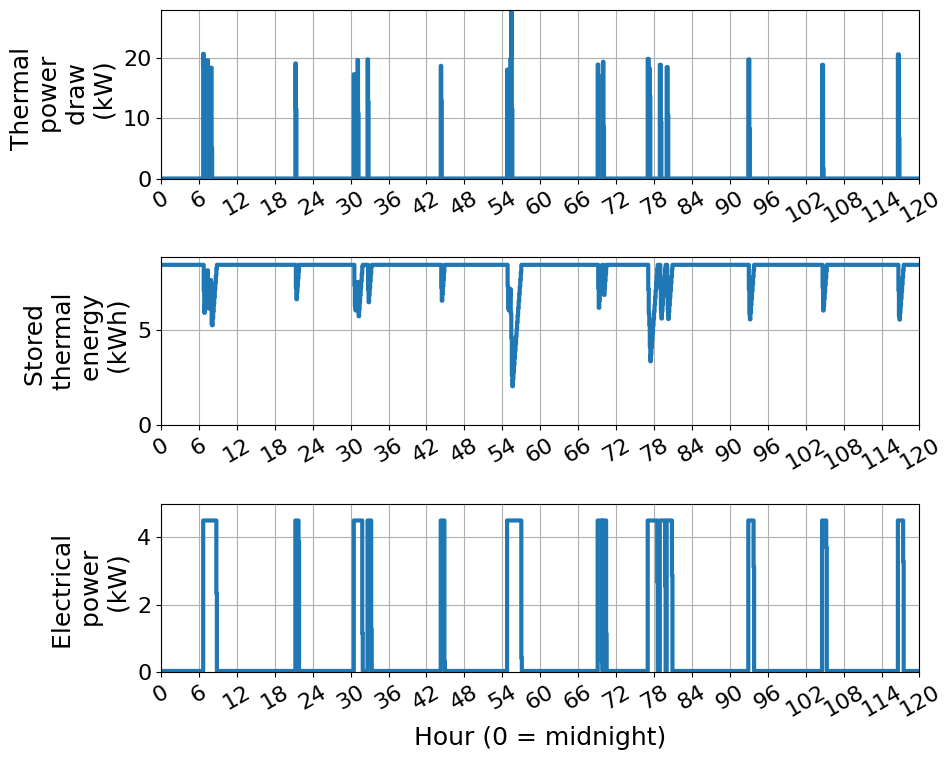

In [107]:

### Resistance-only simulation
# parameters
prMax = 4.5  # Heating element capacity, kW
phMax = 0  # Heat pump capacity, kW
xr = xMax  # Energy threshold for resistor turn-on in hybrid case, kWh
eta = 3 * np.ones(K)  # Heat pump coefficient of performance
# simulation
x1, p1 = water_heater_control(x0, xMax, phMax, prMax, a, w, eta, alpha, xr)
# plots
plot_results(t, x1, p1, qd, xMin, xMax, phMax, prMax, xr, 1)


Now let us consider the heat pump only water heater. Assume a maximum power rating of 0.5 kW for the heat pump element and a COP of 3.


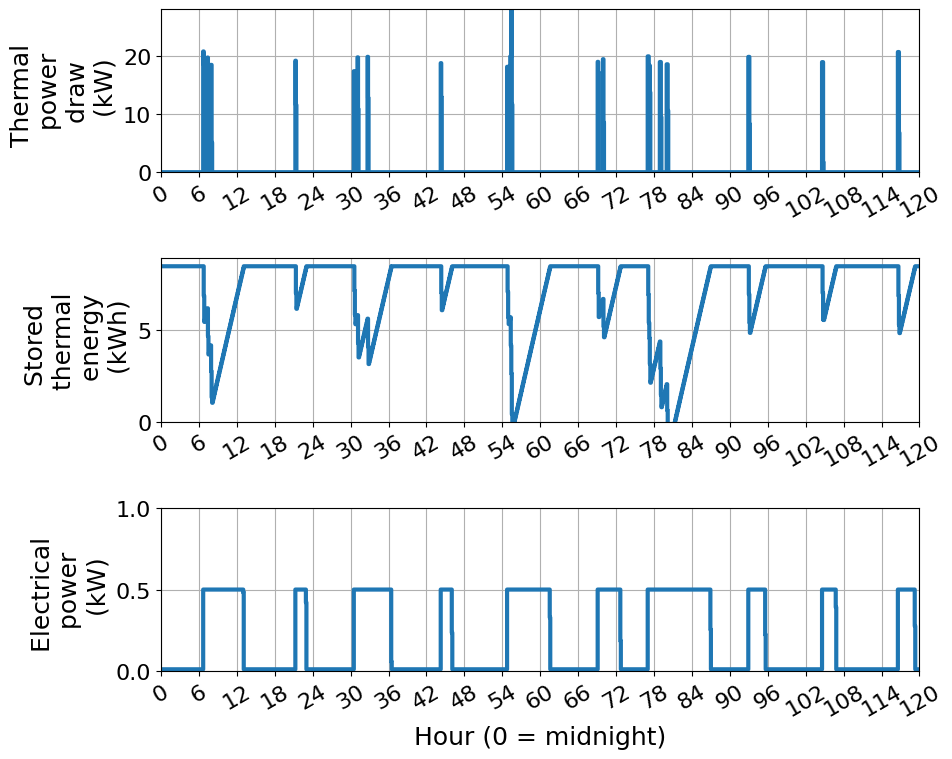

In [108]:

### Heat-pump-only simulation
# parameters
prMax = 0  # Heating element capacity, kW
phMax = 0.5  # Heat pump capacity, kW
xr = 0  # Energy threshold for resistor turn-on in hybrid case, kWh
# simulation
x2, p2 = water_heater_control(x0, xMax, phMax, prMax, a, w, eta, alpha, xr)
# plots
plot_results(t, x2, p2, qd, xMin, xMax, phMax, prMax, xr, 2)


Finally, consider the hybrid heat pump + resistance water heater. Assume the same parameters as above for the heat pump and resistance elements. Let the threshold state of charge $x_r$ be set to 50% of the range of state of charge.

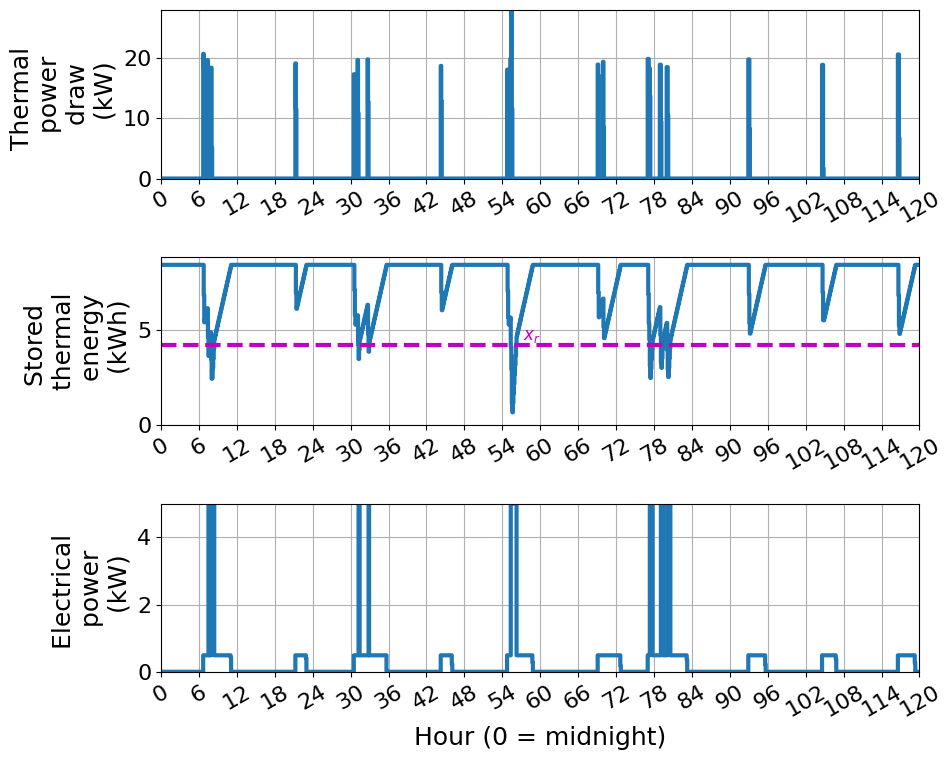

In [109]:

### Hybrid simulation
# parameters
prMax = 4.5  # Heating element capacity, kW
phMax = 0.5  # Heat pump capacity, kW
xr = 0.5 * (xMax - xMin)  # Energy threshold for resistor turn-on in hybrid case, kWh
# simulation
x3, p3 = water_heater_control(x0, xMax, phMax, prMax, a, w, eta, alpha, xr)
# plots

plot_results(t, x3, p3, qd, xMin, xMax, phMax, prMax, xr, 3)
